# Statistics for TrueMeasures

This notebook demonstrates the `Uniform` true measure attributes:

- `mean`
- `standard_deviation`
- `variance`
- `covariance`

It then compares estimates obtained with:

- `DigitalNetB2`, a low discrepancy sampler
- `IIDStdUniform`, sampler for ordinary independent Monte Carlo sampling

In [4]:
import numpy as np
import pandas as pd
import qmcpy as qp
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)

## 1. Create the target uniform distribution

The target distribution is uniform on $[-2,4] \times [1,10]$. Its coordinates are independent, so the covariance matrix is diagonal.

In [5]:
dimension = 2
lower_bound = np.array([-2.0, 1.0])
upper_bound = np.array([4.0, 10.0])

tm = qp.Uniform(
    qp.DigitalNetB2(dimension=dimension, seed=7),
    lower_bound=lower_bound,
    upper_bound=upper_bound,
)

print(tm)

Uniform (AbstractTrueMeasure)
    lower_bound     [-2.  1.]
    upper_bound     [ 4. 10.]
    mean            [1.  5.5]
    variance        [3.   6.75]
    standard_deviation [1.732 2.598]
    covariance      [[3.   0.  ]
                     [0.   6.75]]


## 2. Display the exact attributes

These are theoretical distribution statistics computed from the bounds, not estimates from generated samples.

In [6]:
print("Mean:")
print(tm.mean)
print("Mean Shape:")
print(tm.mean.shape)

print("\nStandard Deviation:")
print(tm.standard_deviation)
print("Standard Deviation Shape:")
print(tm.standard_deviation.shape)

print("\nVariance:")
print(tm.variance)
print("Variance Shape:")
print(tm.variance.shape)

print("\nCovariance:")
print(tm.covariance)
print("Covariance Shape:")
print(tm.covariance.shape)

Mean:
[1.  5.5]
Mean Shape:
(2,)

Standard Deviation:
[1.732 2.598]
Standard Deviation Shape:
(2,)

Variance:
[3.   6.75]
Variance Shape:
(2,)

Covariance:
[[3.   0.  ]
 [0.   6.75]]
Covariance Shape:
(2, 2)


## 3. Compare samples from DigitalNetB2 and IIDStdUniform

Both samplers use $n=256$.

In [7]:
n_demo = 2**8

digital_measure = qp.Uniform(
    qp.DigitalNetB2(dimension=dimension, seed=19),
    lower_bound=lower_bound,
    upper_bound=upper_bound,
)

iid_measure = qp.Uniform(
    qp.IIDStdUniform(dimension=dimension, seed=19),
    lower_bound=lower_bound,
    upper_bound=upper_bound,
)

x_digital = digital_measure(n_demo)
x_iid = iid_measure(n_demo)

digital_mean = x_digital.mean(axis=0)
digital_standard_deviation = x_digital.std(axis=0, ddof=0)
digital_variance = x_digital.var(axis=0, ddof=0)
digital_covariance = np.cov(x_digital, rowvar=False, ddof=0)

iid_mean = x_iid.mean(axis=0)
iid_standard_deviation = x_iid.std(axis=0, ddof=0)
iid_variance = x_iid.var(axis=0, ddof=0)
iid_covariance = np.cov(x_iid, rowvar=False, ddof=0)

print("DigitalNetB2 mean:", np.round(digital_mean, 3))
print("IIDStdUniform mean:", np.round(iid_mean, 3))

print("\nDigitalNetB2 standard deviation:", np.round(digital_standard_deviation, 3))
print("IIDStdUniform standard deviation:", np.round(iid_standard_deviation, 3))

print("\nDigitalNetB2 variance:", np.round(digital_variance, 3))
print("IIDStdUniform variance:", np.round(iid_variance, 3))

print("\nDigitalNetB2 covariance:\n", np.round(digital_covariance, 3))
print("IIDStdUniform covariance:\n", np.round(iid_covariance, 3))

DigitalNetB2 mean: [1.  5.5]
IIDStdUniform mean: [0.889 5.452]

DigitalNetB2 standard deviation: [1.732 2.598]
IIDStdUniform standard deviation: [1.733 2.583]

DigitalNetB2 variance: [3.001 6.75 ]
IIDStdUniform variance: [3.005 6.67 ]

DigitalNetB2 covariance:
 [[3.001 0.   ]
 [0.    6.75 ]]
IIDStdUniform covariance:
 [[3.005 0.215]
 [0.215 6.67 ]]


In [8]:
demo_comparison = pd.DataFrame(
    {
        "statistic": [
            "mean[0]", "mean[1]",
            "standard_deviation[0]", "standard_deviation[1]",
            "variance[0]", "variance[1]",
            "covariance[0,0]", "covariance[0,1]",
            "covariance[1,0]", "covariance[1,1]",
        ],
        "true value": [
            tm.mean[0], tm.mean[1],
            tm.standard_deviation[0], tm.standard_deviation[1],
            tm.variance[0], tm.variance[1],
            tm.covariance[0,0], tm.covariance[0,1],
            tm.covariance[1,0], tm.covariance[1,1],
        ],
        "DigitalNetB2 estimate": [
            digital_mean[0], digital_mean[1],
            digital_standard_deviation[0], digital_standard_deviation[1],
            digital_variance[0], digital_variance[1],
            digital_covariance[0,0], digital_covariance[0,1],
            digital_covariance[1,0], digital_covariance[1,1],
        ],
        "IID estimate": [
            iid_mean[0], iid_mean[1],
            iid_standard_deviation[0], iid_standard_deviation[1],
            iid_variance[0], iid_variance[1],
            iid_covariance[0,0], iid_covariance[0,1],
            iid_covariance[1,0], iid_covariance[1,1],
        ],
    }
)

demo_comparison["DigitalNetB2 absolute error"] = np.abs(
    demo_comparison["DigitalNetB2 estimate"] - demo_comparison["true value"]
)
demo_comparison["IID absolute error"] = np.abs(
    demo_comparison["IID estimate"] - demo_comparison["true value"]
)

demo_comparison.style.format(precision=3).hide(axis='index')

statistic,true value,DigitalNetB2 estimate,IID estimate,DigitalNetB2 absolute error,IID absolute error
mean[0],1.000,1.000,0.889,0.000,0.111
mean[1],5.500,5.500,5.452,0.000,0.048
standard_deviation[0],1.732,1.732,1.733,0.000,0.001
standard_deviation[1],2.598,2.598,2.583,0.000,0.015
variance[0],3.000,3.001,3.005,0.001,0.005
variance[1],6.750,6.750,6.670,0.000,0.080
"covariance[0,0]",3.000,3.001,3.005,0.001,0.005
"covariance[0,1]",0.000,0.000,0.215,0.000,0.215
"covariance[1,0]",0.000,0.000,0.215,0.000,0.215
"covariance[1,1]",6.750,6.750,6.670,0.000,0.080


## 4. Visualize point coverage

At the same sample size, `DigitalNetB2` generally fills the rectangle more evenly than IID sampling.

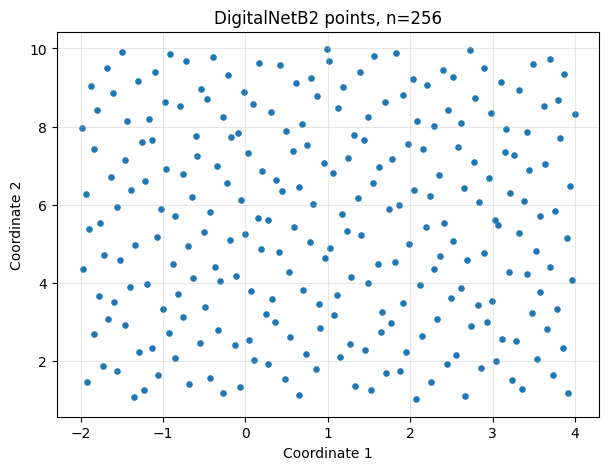

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(x_digital[:, 0], x_digital[:, 1], s=14)
plt.xlabel("Coordinate 1")
plt.ylabel("Coordinate 2")
plt.title(f"DigitalNetB2 points, n={n_demo}")
plt.grid(True, alpha=0.3)
plt.show()

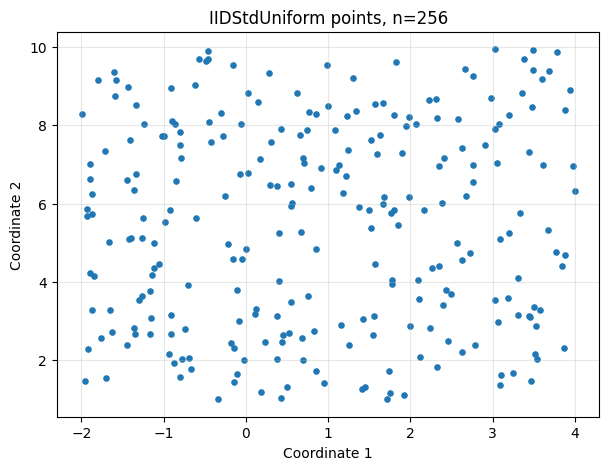

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(x_iid[:, 0], x_iid[:, 1], s=14)
plt.xlabel("Coordinate 1")
plt.ylabel("Coordinate 2")
plt.title(f"IIDStdUniform points, n={n_demo}")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Replication based convergence experiment

For each sample size, this cell computes RMSE over 32 independent replications for both samplers.

In [23]:
sample_sizes = 2 ** np.arange(4, 14)
replications = 32
base_seed = 2026
records = []

for n in sample_sizes:
    digital_measure = qp.Uniform(
        qp.DigitalNetB2(
            dimension=dimension,
            replications=replications,
            seed=base_seed,
        ),
        lower_bound=lower_bound,
        upper_bound=upper_bound,
    )
    iid_measure = qp.Uniform(
        qp.IIDStdUniform(
            dimension=dimension,
            replications=replications,
            seed=base_seed,
        ),
        lower_bound=lower_bound,
        upper_bound=upper_bound,
    )

    digital_samples = digital_measure(int(n))
    iid_samples = iid_measure(int(n))

    digital_means = digital_samples.mean(axis=1)
    iid_means = iid_samples.mean(axis=1)

    digital_standard_deviations = digital_samples.std(axis=1, ddof=0)
    iid_standard_deviations = iid_samples.std(axis=1, ddof=0)

    digital_variances = digital_samples.var(axis=1, ddof=0)
    iid_variances = iid_samples.var(axis=1, ddof=0)

    digital_centered = digital_samples - digital_means[:, None, :]
    iid_centered = iid_samples - iid_means[:, None, :]

    digital_covariances = np.einsum(
        "rni,rnj->rij", digital_centered, digital_centered
    ) / n
    iid_covariances = np.einsum(
        "rni,rnj->rij", iid_centered, iid_centered
    ) / n

    records.extend([
        {"n": int(n), "sampler": "DigitalNetB2", "statistic": "mean",
         "rmse": np.sqrt(np.mean((digital_means - tm.mean) ** 2))},
        {"n": int(n), "sampler": "IIDStdUniform", "statistic": "mean",
         "rmse": np.sqrt(np.mean((iid_means - tm.mean) ** 2))},
        {"n": int(n), "sampler": "DigitalNetB2", "statistic": "standard_deviation",
         "rmse": np.sqrt(np.mean((digital_standard_deviations - tm.standard_deviation) ** 2))},
        {"n": int(n), "sampler": "IIDStdUniform", "statistic": "standard_deviation",
         "rmse": np.sqrt(np.mean((iid_standard_deviations - tm.standard_deviation) ** 2))},
        {"n": int(n), "sampler": "DigitalNetB2", "statistic": "variance",
         "rmse": np.sqrt(np.mean((digital_variances - tm.variance) ** 2))},
        {"n": int(n), "sampler": "IIDStdUniform", "statistic": "variance",
         "rmse": np.sqrt(np.mean((iid_variances - tm.variance) ** 2))},
        {"n": int(n), "sampler": "DigitalNetB2", "statistic": "covariance",
         "rmse": np.sqrt(np.mean((digital_covariances - tm.covariance) ** 2))},
        {"n": int(n), "sampler": "IIDStdUniform", "statistic": "covariance",
         "rmse": np.sqrt(np.mean((iid_covariances - tm.covariance) ** 2))},
    ])

results = pd.DataFrame(records)

summary = (
    results.pivot(
        index=["sampler", "n"],
        columns="statistic",
        values="rmse",
    )
    .reset_index()
)

summary = summary[
    [
        "sampler",
        "n",
        "covariance",
        "mean",
        "standard_deviation",
        "variance",
    ]
]

summary.columns = [
    "Sampler",
    "n",
    "Covariance",
    "Mean",
    "Standard Deviation",
    "Variance",
]

summary["Sampler"] = summary["Sampler"].mask(
    summary["Sampler"].duplicated(), ""
)

summary.style.format(
    {
        "Covariance": "{:.3f}",
        "Mean": "{:.3f}",
        "Standard Deviation": "{:.3f}",
        "Variance": "{:.3f}",
    }
).hide(axis="index")

Sampler,n,Covariance,Mean,Standard Deviation,Variance
DigitalNetB2,16,0.239,0.040,0.043,0.206
,32,0.109,0.009,0.015,0.077
,64,0.029,0.002,0.003,0.015
,128,0.016,0.001,0.002,0.010
,256,0.006,0.000,0.000,0.001
,512,0.001,0.000,0.000,0.001
,1024,0.000,0.000,0.000,0.000
,2048,0.000,0.000,0.000,0.000
,4096,0.000,0.000,0.000,0.000
,8192,0.000,0.000,0.000,0.000


## 6. Convergence plots

Lower RMSE means the estimate is closer to the exact statistic. Steeper downward curves indicate faster observed convergence.

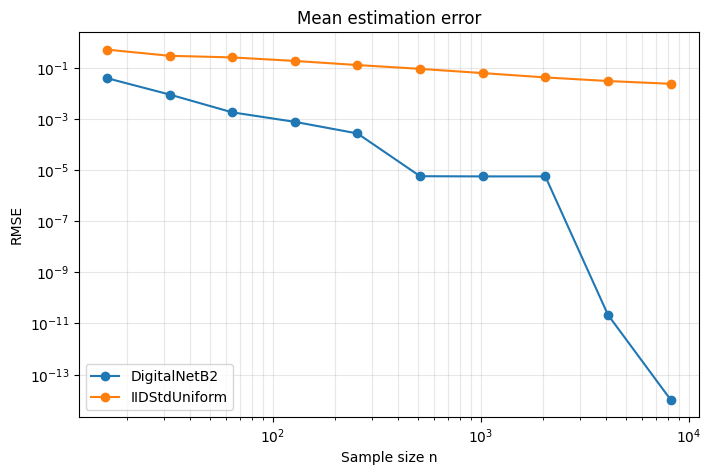

In [24]:
plot_data = results[results["statistic"] == "mean"]

digital_plot = plot_data[
    plot_data["sampler"] == "DigitalNetB2"
].sort_values("n")

iid_plot = plot_data[
    plot_data["sampler"] == "IIDStdUniform"
].sort_values("n")

plt.figure(figsize=(8, 5))
plt.loglog(
    digital_plot["n"],
    digital_plot["rmse"],
    marker="o",
    label="DigitalNetB2",
)
plt.loglog(
    iid_plot["n"],
    iid_plot["rmse"],
    marker="o",
    label="IIDStdUniform",
)
plt.xlabel("Sample size n")
plt.ylabel("RMSE")
plt.title("Mean estimation error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

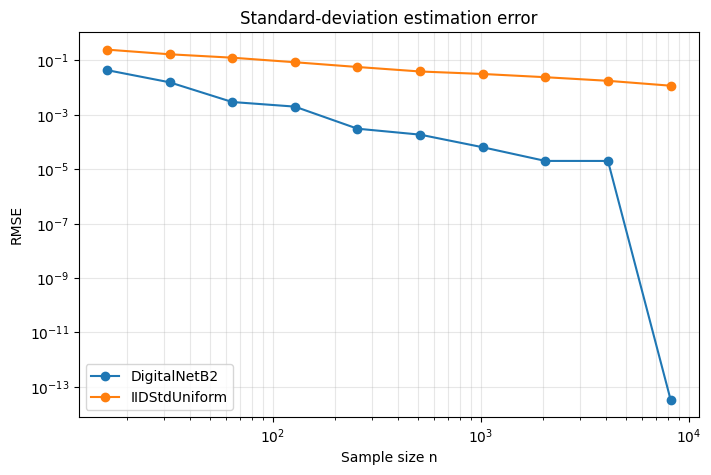

In [14]:
plot_data = results[results["statistic"] == "standard_deviation"]

digital_plot = plot_data[
    plot_data["sampler"] == "DigitalNetB2"
].sort_values("n")

iid_plot = plot_data[
    plot_data["sampler"] == "IIDStdUniform"
].sort_values("n")

plt.figure(figsize=(8, 5))
plt.loglog(
    digital_plot["n"],
    digital_plot["rmse"],
    marker="o",
    label="DigitalNetB2",
)
plt.loglog(
    iid_plot["n"],
    iid_plot["rmse"],
    marker="o",
    label="IIDStdUniform",
)
plt.xlabel("Sample size n")
plt.ylabel("RMSE")
plt.title("Standard-deviation estimation error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

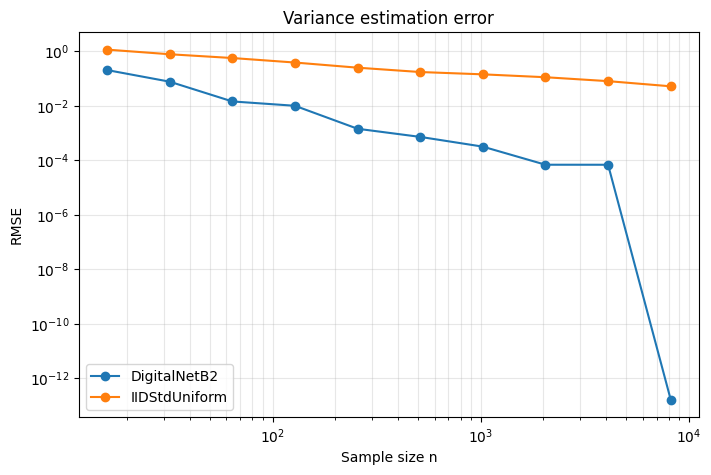

In [15]:
plot_data = results[results["statistic"] == "variance"]

digital_plot = plot_data[
    plot_data["sampler"] == "DigitalNetB2"
].sort_values("n")

iid_plot = plot_data[
    plot_data["sampler"] == "IIDStdUniform"
].sort_values("n")

plt.figure(figsize=(8, 5))
plt.loglog(
    digital_plot["n"],
    digital_plot["rmse"],
    marker="o",
    label="DigitalNetB2",
)
plt.loglog(
    iid_plot["n"],
    iid_plot["rmse"],
    marker="o",
    label="IIDStdUniform",
)
plt.xlabel("Sample size n")
plt.ylabel("RMSE")
plt.title("Variance estimation error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

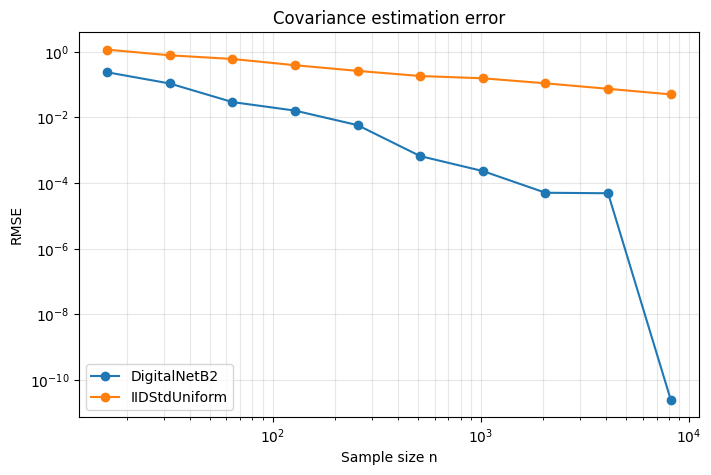

In [16]:
plot_data = results[results["statistic"] == "covariance"]

digital_plot = plot_data[
    plot_data["sampler"] == "DigitalNetB2"
].sort_values("n")

iid_plot = plot_data[
    plot_data["sampler"] == "IIDStdUniform"
].sort_values("n")

plt.figure(figsize=(8, 5))
plt.loglog(
    digital_plot["n"],
    digital_plot["rmse"],
    marker="o",
    label="DigitalNetB2",
)
plt.loglog(
    iid_plot["n"],
    iid_plot["rmse"],
    marker="o",
    label="IIDStdUniform",
)
plt.xlabel("Sample size n")
plt.ylabel("RMSE")
plt.title("Covariance estimation error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## Interpretation

`DigitalNetB2` shows a lower replication averaged error and a much faster decrease in error than `IIDStdUniform`.